In [22]:
# Load Dataset
import pandas as pd


df = pd.read_csv("bank.csv")

X = df.drop(['poutcome', 'deposit'], axis=1)
y = df['deposit'].map({"yes": 1, "no": 0})

for col in X.select_dtypes(include='str').columns:
    print(col, df[col].unique(), "\n")

# print(X.info())


job <StringArray>
[       'admin.',    'technician',      'services',    'management',
       'retired',   'blue-collar',    'unemployed',  'entrepreneur',
     'housemaid',       'unknown', 'self-employed',       'student']
Length: 12, dtype: str 

marital <StringArray>
['married', 'single', 'divorced']
Length: 3, dtype: str 

education <StringArray>
['secondary', 'tertiary', 'primary', 'unknown']
Length: 4, dtype: str 

default <StringArray>
['no', 'yes']
Length: 2, dtype: str 

housing <StringArray>
['yes', 'no']
Length: 2, dtype: str 

loan <StringArray>
['no', 'yes']
Length: 2, dtype: str 

contact <StringArray>
['unknown', 'cellular', 'telephone']
Length: 3, dtype: str 

month <StringArray>
['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'jan', 'feb', 'mar', 'apr',
 'sep']
Length: 12, dtype: str 



In [3]:
# Split data into 80/20 ratio
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
# Preprocess & Model's pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier


cate_cols = [cols for cols in X.select_dtypes(include='str').columns]

preprocess = ColumnTransformer(
    transformers = [
        ('encode_cols', OneHotEncoder(handle_unknown='ignore'), cate_cols)
    ],
    remainder='passthrough'
)

pipeline = Pipeline([
    ('preprocessor', preprocess),
    ('model', XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42))
])

In [11]:
# Hypertune model
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_dist = {
    "model__n_estimators": [100, 300, 500], 
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth":  [3, 5, 7, 9],
    "model__min_child_weight": [1, 3, 5],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__gamma": [0, 0.1, 0.3, 0.5],
    "model__reg_alpha": [0, 0.1, 1],
    "model__reg_lambda": [1, 3, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rs_cv = RandomizedSearchCV(
    pipeline,
    param_dist,
    n_iter=20,
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [12]:
# Train model
rs_cv.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.6, 0.8, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made avai

In [13]:
predictions = rs_cv.predict(X_test)
print(predictions)

print(rs_cv.best_params_)

[0 1 1 ... 1 1 1]
{'model__subsample': 0.8, 'model__reg_lambda': 5, 'model__reg_alpha': 0.1, 'model__n_estimators': 300, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__gamma': 0.3, 'model__colsample_bytree': 1.0}


In [14]:
# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, recall_score

print(classification_report(y_test, predictions))
print(f"\n\nConfusion Matrix\n{confusion_matrix(y_test, predictions)}")

train_recall = rs_cv.predict(X_train)
print(f"\n\nTraining Recall : {round(recall_score(y_train,train_recall)*100, 2)}%")
print(f"Test Recall : {round(recall_score(y_test, predictions)*100, 2)}%")

              precision    recall  f1-score   support

           0       0.89      0.85      0.87      1175
           1       0.84      0.89      0.87      1058

    accuracy                           0.87      2233
   macro avg       0.87      0.87      0.87      2233
weighted avg       0.87      0.87      0.87      2233



Confusion Matrix
[[1000  175]
 [ 118  940]]


Training Recall : 94.33%
Test Recall : 88.85%


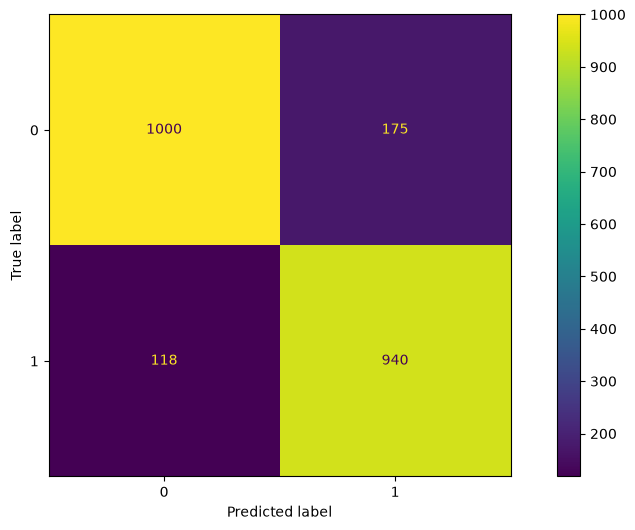

In [16]:
# Plot Confusion Matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(12, 6))

ConfusionMatrixDisplay.from_predictions(y_test, predictions, ax=ax)

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

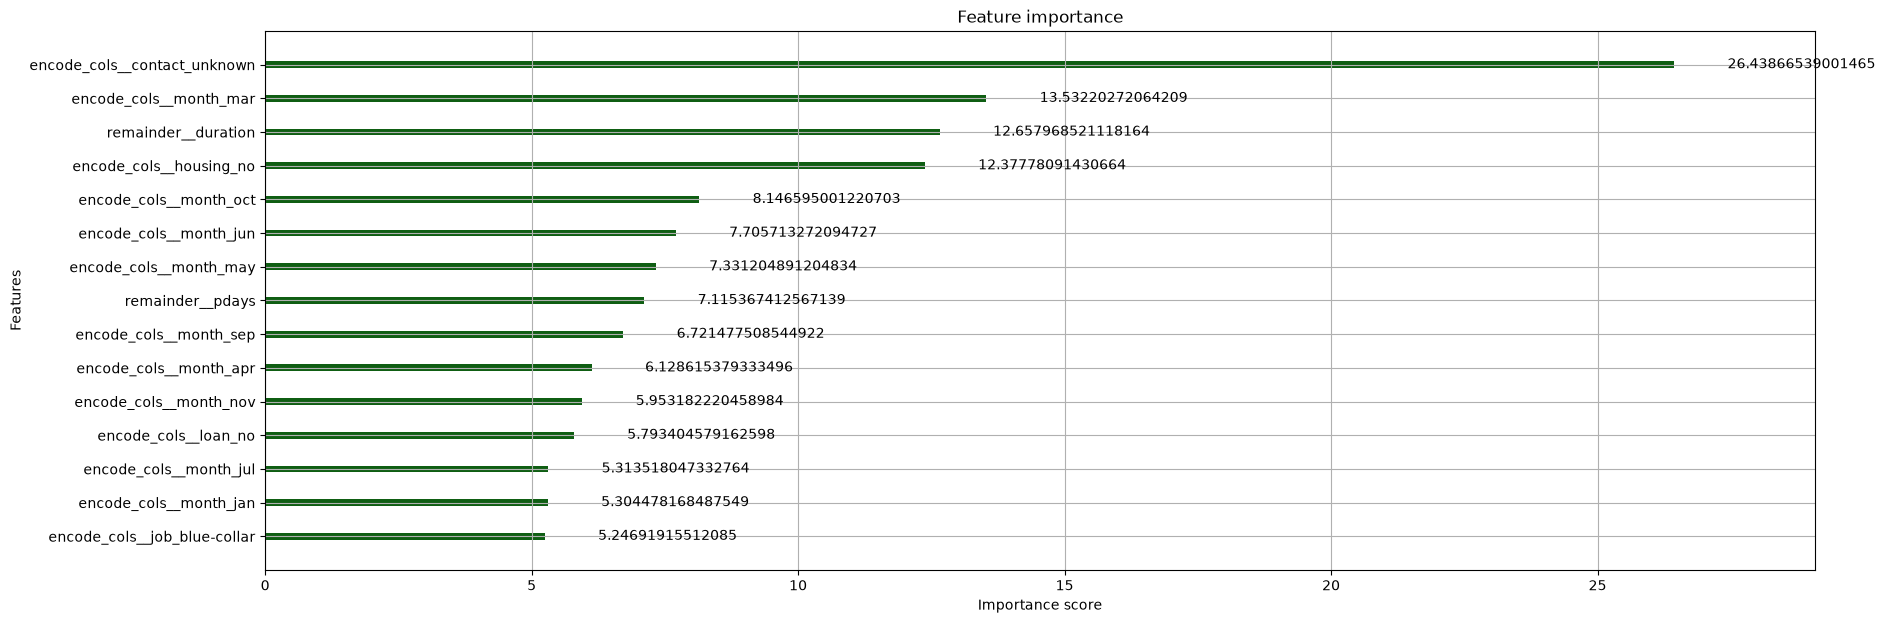

In [21]:
# Plot Model's Feature Importance
import xgboost as xgb
fig, ax = plt.subplots(figsize=(20, 7))

best_estimator = rs_cv.best_estimator_
model = best_estimator.named_steps['model']
encoded_cols = best_estimator.named_steps['preprocessor'].get_feature_names_out()

model.get_booster().feature_names = list(encoded_cols)

xgb.plot_importance(
    model,
    ax=ax,
    max_num_features=15,
    importance_type='gain',
    color="#0F5E13"
)
